#  Model Interpretability & Fairness Analysis
SHAP · Fairness · LIME · DiCE

---
##  Import

In [1]:
import os, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

warnings.filterwarnings("ignore")

# Fix tqdm bug
import os
os.environ["TQDM_DISABLE"] = "1"

c:\Users\lanph\anaconda3\envs\python10-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Load Model + Data

In [2]:
data_dir = r"C:\Users\lanph\OneDrive\Desktop\Introduction to Data Science\Final_Project\Adult_Project_Final_Term\Material\models"
INPUT_BASE = r"C:\Users\lanph\OneDrive\Desktop\Introduction to Data Science\Final_Project\Adult_Project_Final_Term\data\processed"
model = joblib.load(os.path.join(data_dir, "lgbm.pkl"))
test = pd.read_csv(os.path.join(INPUT_BASE, "adult_features_test.csv"))

X_test = test.drop(columns=["income"])
y_test = test["income"].astype(int)

clf = model.named_steps["clf"]

print("Model:", type(clf))
print("Shape:", X_test.shape)

Model: <class 'lightgbm.sklearn.LGBMClassifier'>
Shape: (9769, 39)


---
## SHAP Analysis

In [5]:
print("\nSHAP ANALYSIS ")

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values


SHAP ANALYSIS 


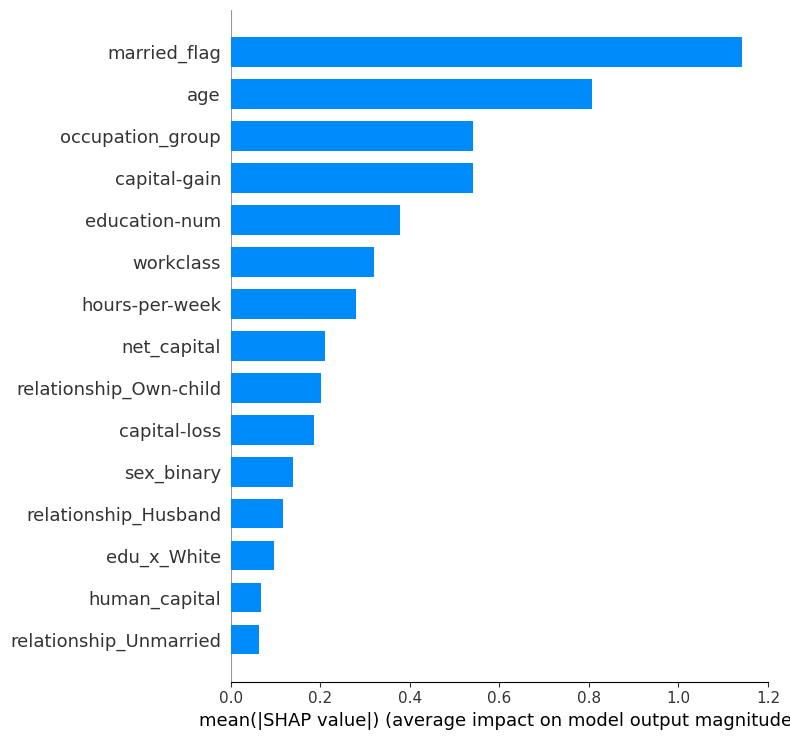

In [6]:
# --- Feature importance
plt.figure(figsize=(10, 5))
shap.summary_plot(sv, X_test, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.show()

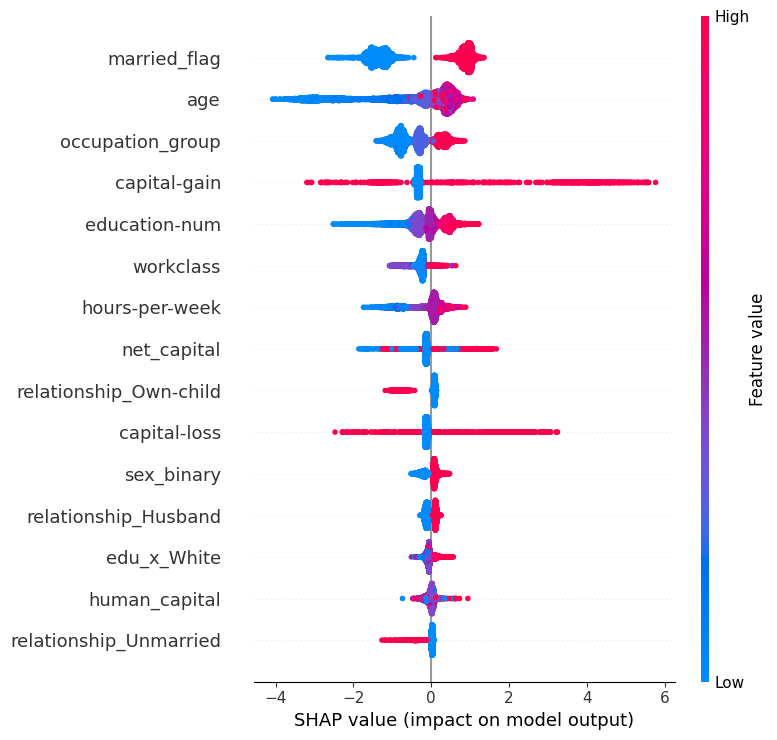

In [7]:
# --- Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, max_display=15, show=False)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

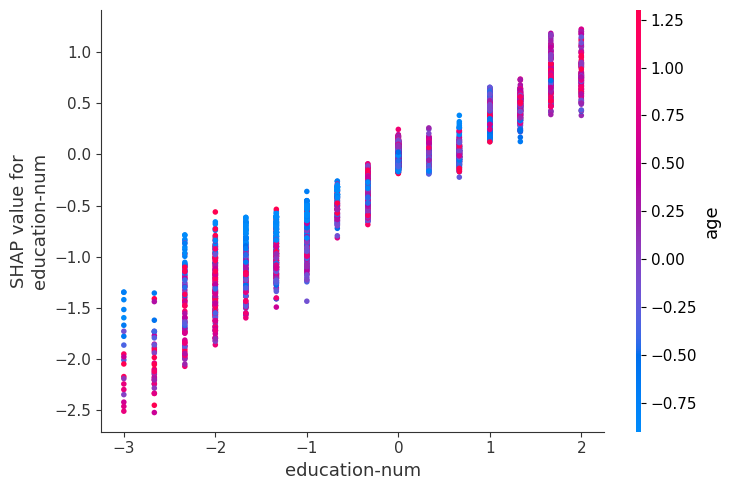

<Figure size 800x500 with 0 Axes>

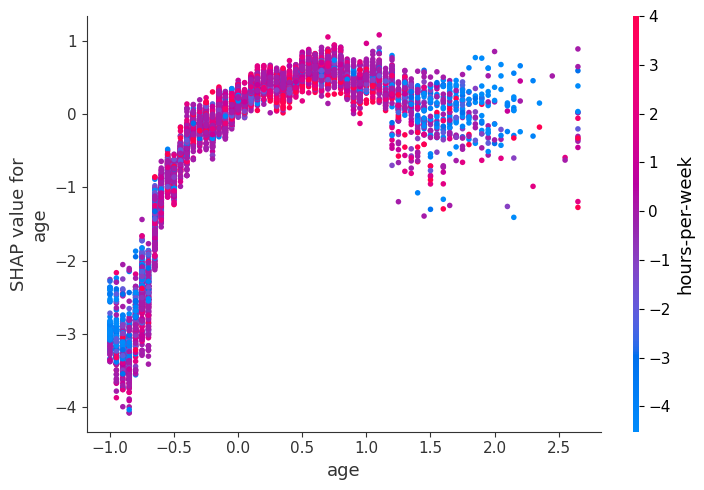

<Figure size 800x500 with 0 Axes>

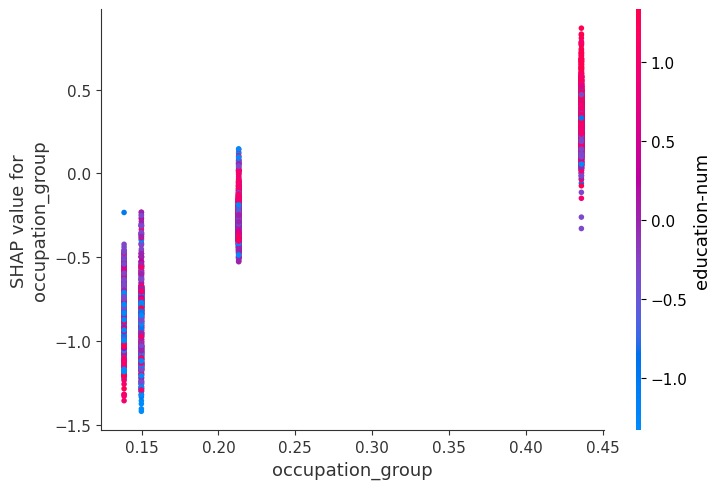

In [8]:
# --- Dependence (normal)
pairs = [
    ("education-num", "age"),
    ("age", "hours-per-week"),
    ("occupation_group", "education-num")
]

for feat, interact in pairs:
    if feat in X_test.columns:
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(feat, sv, X_test, interaction_index=interact, show=False)
        plt.tight_layout()
        plt.show()

---
##  SHAP Bias Analysis


 SHAP BIAS ANALYSIS 


<Figure size 800x500 with 0 Axes>

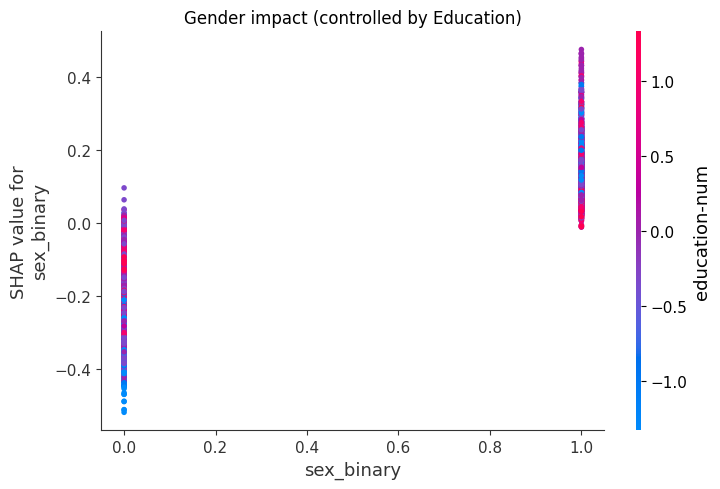

<Figure size 800x500 with 0 Axes>

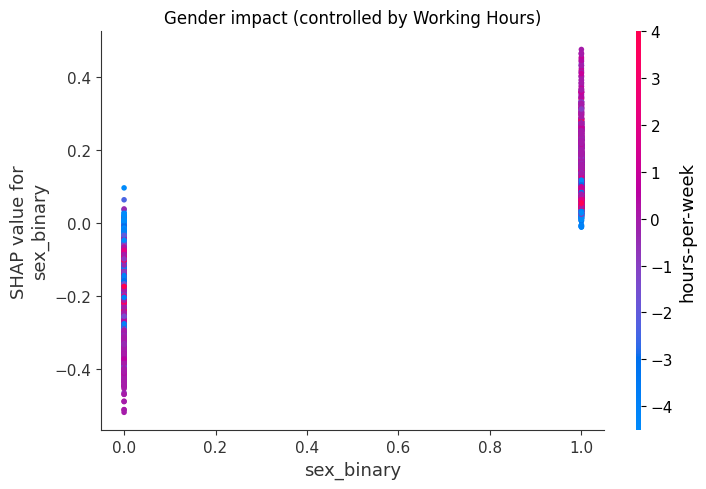

<Figure size 800x500 with 0 Axes>

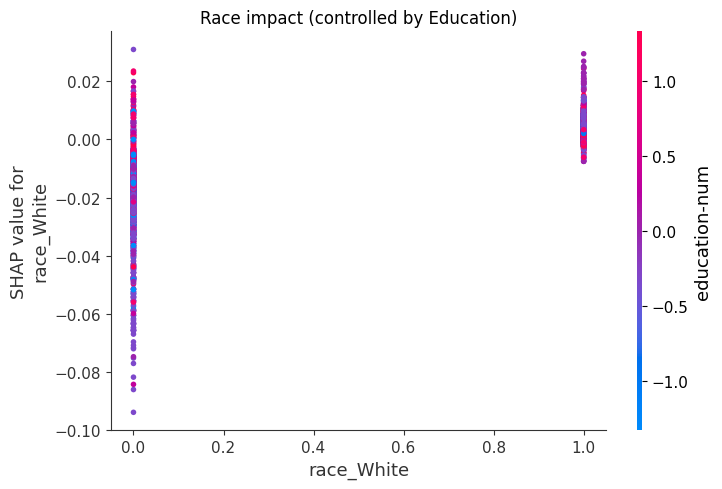

In [9]:
print("\n SHAP BIAS ANALYSIS ")

# Gender vs Education
if "sex_binary" in X_test.columns and "education-num" in X_test.columns:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        "sex_binary",
        sv,
        X_test,
        interaction_index="education-num",
        show=False
    )
    plt.title("Gender impact (controlled by Education)")
    plt.tight_layout()
    plt.show()

# Gender vs Working Hours
if "sex_binary" in X_test.columns and "hours-per-week" in X_test.columns:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        "sex_binary",
        sv,
        X_test,
        interaction_index="hours-per-week",
        show=False
    )
    plt.title("Gender impact (controlled by Working Hours)")
    plt.tight_layout()
    plt.show()

# Race vs Education
if "race_White" in X_test.columns and "education-num" in X_test.columns:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        "race_White",
        sv,
        X_test,
        interaction_index="education-num",
        show=False
    )
    plt.title("Race impact (controlled by Education)")
    plt.tight_layout()
    plt.show()

In [10]:
# --- Ranking
shap_importance = np.abs(sv).mean(axis=0)
feat_rank = pd.DataFrame({
    "feature": X_test.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

print("\nTop SHAP Features:")
print(feat_rank.head(10))

# --- Sensitive feature impact
for sensitive in ["sex_binary", "race_White"]:
    if sensitive in X_test.columns:
        idx = list(X_test.columns).index(sensitive)
        print(f"\n{sensitive}:")
        print(f"  Mean |SHAP| = {np.abs(sv[:, idx]).mean():.4f}")
        print(f"  Mean SHAP = {sv[:, idx].mean():.4f}")


Top SHAP Features:
                   feature  importance
8             married_flag    1.143159
0                      age    0.806431
7         occupation_group    0.542064
3             capital-gain    0.541074
2            education-num    0.377433
1                workclass    0.321095
5           hours-per-week    0.280055
23             net_capital    0.211295
12  relationship_Own-child    0.201054
4             capital-loss    0.185843

sex_binary:
  Mean |SHAP| = 0.1398
  Mean SHAP = 0.0017

race_White:
  Mean |SHAP| = 0.0055
  Mean SHAP = -0.0000



Explaining instance index: 11


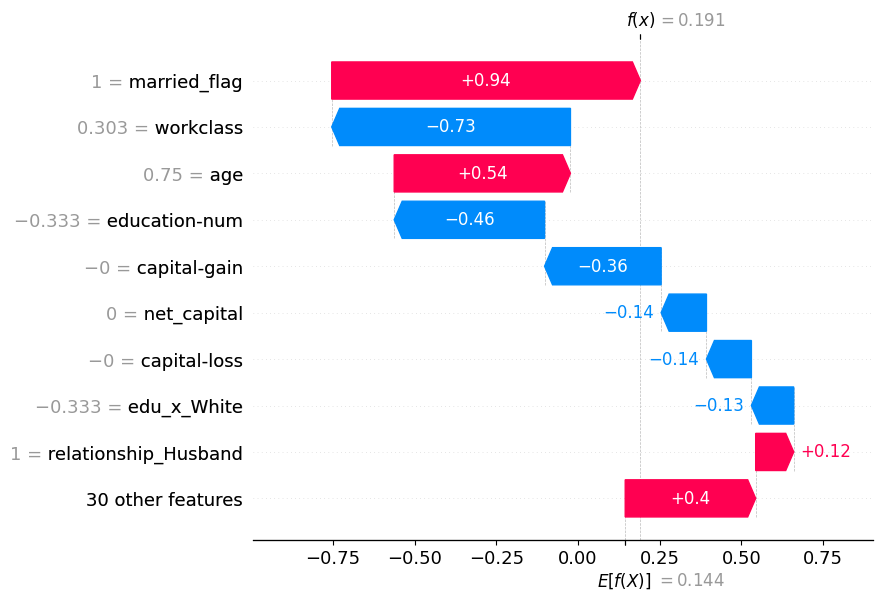

In [11]:
# --- Local explanation
y_pred = model.predict(X_test)
wrong_idx_candidates = np.where((y_pred == 1) & (y_test.values == 0))[0]
wrong_idx = wrong_idx_candidates[0] if len(wrong_idx_candidates) > 0 else 0

print("\nExplaining instance index:", wrong_idx)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(
    shap.Explanation(
        values=sv[wrong_idx],
        base_values=explainer.expected_value[1]
        if isinstance(explainer.expected_value, list)
        else explainer.expected_value,
        data=X_test.iloc[wrong_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10
)
plt.show()

---
##  Fairness

In [12]:
print("\nFAIRNESS ")

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from sklearn.metrics import accuracy_score, recall_score

y_pred = model.predict(X_test)

print("\n--- FULL DATA ---")
for feat in ["sex_binary", "race_White"]:
    if feat in X_test.columns:
        dpd = demographic_parity_difference(y_test, y_pred,
                                            sensitive_features=X_test[feat])
        dpr = demographic_parity_ratio(y_test, y_pred,
                                      sensitive_features=X_test[feat])
        eod = equalized_odds_difference(y_test, y_pred,
                                        sensitive_features=X_test[feat])

        print(f"\n[{feat}]")
        print(f"DPD = {dpd:.4f}")
        print(f"DPR = {dpr:.4f}")
        print(f"EOD = {eod:.4f}")


FAIRNESS 

--- FULL DATA ---

[sex_binary]
DPD = 0.2612
DPR = 0.2739
EOD = 0.1533

[race_White]
DPD = 0.1525
DPR = 0.4812
EOD = 0.1397


---
## LIME

In [13]:
print("\nLIME ")

from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    training_data=X_test.values,
    feature_names=X_test.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp_lime = explainer_lime.explain_instance(
    X_test.iloc[wrong_idx].values,
    clf.predict_proba,
    num_features=10
)

print("\nLIME Explanation:")
print(exp_lime.as_list())


LIME 

LIME Explanation:
[('capital_x_Amer-Indian-Eskimo <= 0.00', 0.3003488868603296), ('capital-gain <= 0.00', 0.1787570096127005), ('capital_x_Other <= 0.00', -0.17236385303387414), ('workclass > 0.21', 0.16767685680950448), ('edu_x_Amer-Indian-Eskimo <= 0.00', 0.1572724786395288), ('age > 0.55', 0.14720524721854236), ('capital-loss <= 0.00', -0.11814745699672809), ('relationship_Other-relative <= 0.00', 0.1139077335761829), ('0.00 < married_flag <= 1.00', 0.0981821123010966), ('hours_x_Asian-Pac-Islander <= 0.00', -0.06781518685620071)]


---
##  DiCE

In [14]:
print("\n DiCE ")

import dice_ml
from dice_ml import Dice

class NumericPredictWrapper:
    def __init__(self, estimator, cols):
        self.estimator = estimator
        self.cols = cols

    def _fix(self, X):
        X = pd.DataFrame(X, columns=self.cols)
        return X.apply(pd.to_numeric, errors="coerce")

    def predict_proba(self, X):
        return self.estimator.predict_proba(self._fix(X))

    def predict(self, X):
        return self.estimator.predict(self._fix(X))

X_dice = X_test.copy()

d = dice_ml.Data(
    dataframe=pd.concat([X_dice, y_test.rename("income")], axis=1),
    continuous_features=[
        "age", "education-num",
        "hours-per-week",
        "capital-gain", "capital-loss"
    ],
    outcome_name="income"
)

m = dice_ml.Model(
    model=NumericPredictWrapper(clf, X_test.columns.tolist()),
    backend="sklearn"
)

exp = Dice(d, m, method="genetic")

query = X_dice[y_test == 0].iloc[[0]]

try:
    cf = exp.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        features_to_vary="all"
    )
    print("\nCF results:")
    cf.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print("CF failed:", e)


 DiCE 


100%|██████████| 1/1 [00:03<00:00,  3.72s/it]


CF results:
Query instance (original outcome : 0)


,age,workclass,education-num,capital-gain,capital-loss,hours-per-week,country_income_group,occupation_group,married_flag,relationship_Husband,...,hours_x_Asian-Pac-Islander,hours_x_Black,hours_x_Other,hours_x_White,capital_x_Amer-Indian-Eskimo,capital_x_Asian-Pac-Islander,capital_x_Black,capital_x_Other,capital_x_White,income
0,-0.35,0.213293,-0.333333,-0.0,-0.0,0.0,3,0.138603,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0



Diverse Counterfactual set (new outcome: 1.0)


,age,workclass,education-num,capital-gain,capital-loss,hours-per-week,country_income_group,occupation_group,married_flag,relationship_Husband,...,hours_x_Asian-Pac-Islander,hours_x_Black,hours_x_Other,hours_x_White,capital_x_Amer-Indian-Eskimo,capital_x_Asian-Pac-Islander,capital_x_Black,capital_x_Other,capital_x_White,income
0,-0.3,-,-,-,-,-,-,0.4360339574748772,1.0,1.0,...,-,-,-,-,-,-,-,-,-,1.0
0,-0.1,-,-,-,-,-,-,-,1.0,1.0,...,-,-,-,-,-,-,-,-,-,1.0
0,0.0,-,-,-,-,-,-,-,1.0,1.0,...,-,-,-,-,-,-,-,-,-,1.0
